##### Intro to Quantum Programming - Spring 2025
## Homework 4: Due 04/04/25

For each exercise below, add as many cells as you want. To evaluate your submission, I will do **Restart and Run All**. . For help with Markdown, see [this link](https://www.markdownguide.org/).

In [1]:
# Here's a cell for import statements... add more if necessary (or just import below as needed)
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit.library import *
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

import numpy as np
import random
from math import *
import matplotlib.pyplot as plt
from decimal import Decimal, getcontext, Overflow


## Import sv_disc [Python File to Display Quibit States in Disc format]
import sys
# Add the directory where sv_disc.py is located
sys.path.append('/home/connor/QuantumComputing/Qiskit')
from sv_disc import *

For some of the exercises below, you may use high-level circuit from [`qiskit.circuit.library`](https://docs.quantum.ibm.com/api/qiskit/circuit_library). Refer to each problem see what you are and are not allowed to use.

----
#### Exercise 4.1 (40%): QFT Adder

The QFT circuit can be used as a building block for basic arithmetic, as discussed in [this blog](https://pennylane.ai/qml/demos/tutorial_qft_arithmetics) by Pennylane. The QFT allows us to add two quantum registers without using ancilla qubits. The idea is to use QFT to convert into the "frequency" domain. Then use use the other circuit to add phase shifts, which changes the frequency of the signal, and then use inverse-QFT to revert back to a number.

The Pennylane tutorial shows an out-of-band adder: $$|0\rangle|b\rangle|a\rangle \mapsto |a+b\rangle|b\rangle|a\rangle,$$ while Qiskit's `DraperQFTAdder` does an in-place adder: $$|b\rangle|a\rangle \mapsto |a+b\rangle|a\rangle.$$

In the cells below, implement an *in-place* QFT adder for two 4-qubit numbers without using the `DraperQFTAdder` circuit.  In other words, use `QFT` and controlled-`RZ` gates to implement the adder.  To get full points, draw the circuit and demonstrate that it works for multiple choices of $a$ and $b$.

### **Why Does QFT-Based Addition Work?**
##### **Added By Connor**

The in-place QFT adder uses the properties of the **Quantum Fourier Transform (QFT)** to perform addition by modifying the phase of a quantum register.

Instead of simulating classical carry logic, this method performs the addition by encoding numbers in **quantum phases**, adjusting those phases, and then decoding the result back to the computational basis.

---

#### Step-by-Step Explanation

##### 1. What Are Basis States and Superpositions?

In quantum computing, an **n-qubit register** exists in a space spanned by the **computational basis states**:

$$
|0\rangle, |1\rangle, |2\rangle, \dots, |2^n - 1\rangle
$$

These represent binary values from 0 to $2^n - 1$, encoded in qubits. For example, for 3 qubits, the basis states include $|000\rangle, |001\rangle, \dots, |111\rangle$.

A **superposition** is a linear combination of these basis states:

$$
|\psi\rangle = \sum_{k=0}^{2^n - 1} \alpha_k |k\rangle
$$

Here, each $\alpha_k$ is a **complex amplitude**. The square magnitude $|\alpha_k|^2$ is the probability of measuring the state $|k\rangle$.

---

##### 2. What Is a "Superposition of Phases"?

When we say the QFT transforms a state into a "superposition of phases," we mean it converts a basis state like $|b\rangle$ into a quantum state where all basis states $|k\rangle$ are present, but each with a **complex phase factor** based on $b$:

$$
\text{QFT}|b\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i b k / 2^n} |k\rangle
$$

Each amplitude now includes a phase: $e^{2\pi i b k / 2^n}$. This is the key to how QFT encodes numerical values in the **frequency domain**.

---

##### 3. How Does QFT Addition Work?

To add two quantum numbers $a$ and $b$ without using ancilla qubits:

- Prepare a quantum state $|b\rangle|a\rangle$
- Apply the **QFT** to $|b\rangle$, converting it to the phase-encoded state above
- Use **controlled phase rotations** from the $|a\rangle$ qubits to modify the phase of each component in $|b\rangle$
  - This introduces an extra phase factor $e^{2\pi i a k / 2^n}$
  - The combined phase becomes $e^{2\pi i (a + b) k / 2^n}$
- Apply the **inverse QFT** to $|b\rangle$, converting it back into the computational basis

Mathematically:

$$
\frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i (a + b) k / 2^n} |k\rangle \xrightarrow{\text{QFT}^{-1}} |a + b\rangle
$$

Now the $|b\rangle$ register holds $a + b$, while $|a\rangle$ is unchanged.

---

#### 4. What Does the QFT Actually Do?

The **Quantum Fourier Transform** is a unitary operation (reversible) that maps a basis state $|x\rangle$ into a superposition over $|k\rangle$, where each term has a different phase:

$$
\text{QFT}|x\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i x k / 2^n} |k\rangle
$$

This phase encoding is analogous to a classical Discrete Fourier Transform (DFT). It does not destroy information — instead, it redistributes it across phases.

Since the QFT is **unitary**, applying its inverse $\text{QFT}^{-1}$ perfectly reconstructs the original input state.

---

#### 5. Why Is No Information Lost?

Even though phase encoding may seem abstract, **no information is discarded** because:

- The QFT preserves all input data in phase form
- The inverse QFT restores that data
- All operations (QFT, controlled phase gates, and inverse QFT) are **reversible**

In this adder circuit:
- You never measure until the end
- You don’t collapse the wavefunction prematurely
- You only modify phases, which is safe until final measurement

This means your result is **exact**, and you still get a valid, deterministic output: $|a + b\rangle|a\rangle$

---

#### Summary

- The QFT encodes numbers as phase angles in a uniform superposition
- Controlled phase rotations shift those angles based on the second number
- The inverse QFT decodes the result back into the standard basis
- The final state is $|a + b\rangle|a\rangle$, with no ancilla qubits or classical carry logic required


=== Quantum Adder Tests with Visualization ===

Test Case: 1 + 2 = 3
----------------------------------------
Input A:     0001 (decimal: 1)
Input B:     0010 (decimal: 2)
Computed Sum: 0011 (decimal: 3)
Expected Sum: 0011 (decimal: 3)

Non-zero probabilities:
|00110001⟩ → 1.0000

Test Case: 3 + 5 = 8
----------------------------------------
Input A:     0011 (decimal: 3)
Input B:     0101 (decimal: 5)
Computed Sum: 1000 (decimal: 8)
Expected Sum: 1000 (decimal: 8)

Non-zero probabilities:
|10000011⟩ → 1.0000

Test Case: 3 + 5 = 8
----------------------------------------
Input A:     0011 (decimal: 3)
Input B:     0101 (decimal: 5)
Computed Sum: 1000 (decimal: 8)
Expected Sum: 1000 (decimal: 8)

Initial Bloch vectors:


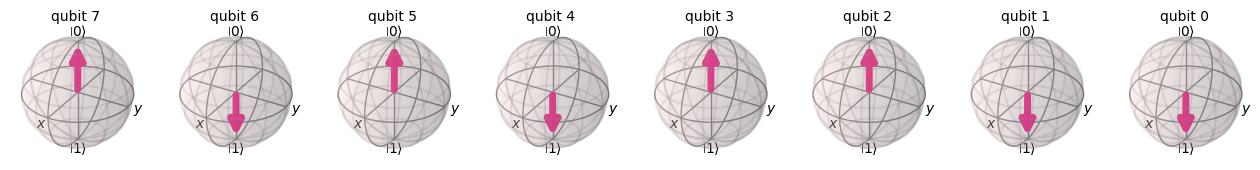


Final Bloch vectors:


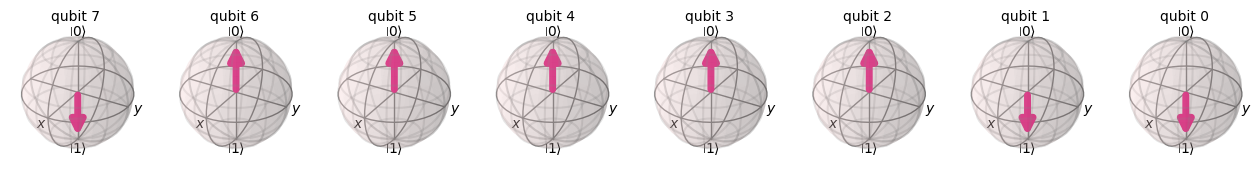


Test Case: 5 + 0 = 5
----------------------------------------
Input A:     0101 (decimal: 5)
Input B:     0000 (decimal: 0)
Computed Sum: 0101 (decimal: 5)
Expected Sum: 0101 (decimal: 5)

Initial Bloch vectors:


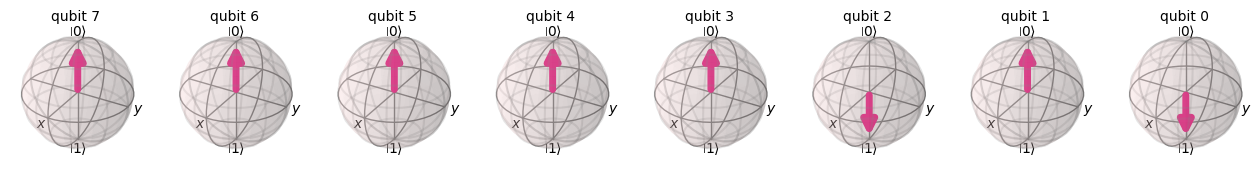


Final Bloch vectors:


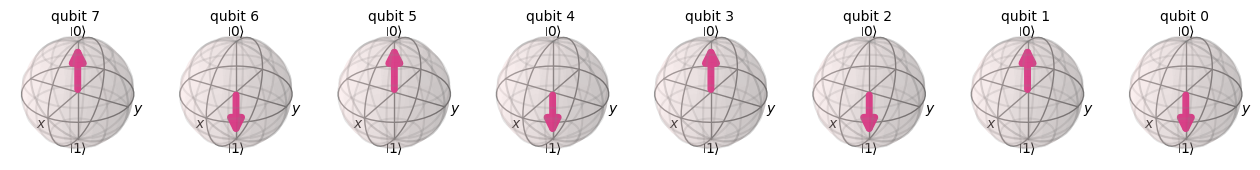


Test Case: 15 + 1 = 0
----------------------------------------
Input A:     1111 (decimal: 15)
Input B:     0001 (decimal: 1)
Computed Sum: 0000 (decimal: 0)
Expected Sum: 0000 (decimal: 0)

Non-zero probabilities:
|00001111⟩ → 1.0000


In [24]:
def run_test(a_val, b_val, expected_sum, a_bits=4, b_bits=4, display_mode="text"):
    """Quantum adder test with visualization options"""
    # Create registers
    qreg_a = QuantumRegister(a_bits, name='a')
    qreg_b = QuantumRegister(b_bits, name='b')
    qc = QuantumCircuit(qreg_a, qreg_b)
    
    # Store original values for display
    original_a = a_val
    original_b = b_val
    
    # Initialize registers (little-endian)
    for i in range(a_bits):
        if (a_val >> i) & 1:
            qc.x(qreg_a[i])
    for i in range(b_bits):
        if (b_val >> i) & 1:
            qc.x(qreg_b[i])

    # Get initial state
    initial_sv = Statevector.from_instruction(qc)
    
    # QFT Adder implementation
    qc.append(QFT(b_bits, do_swaps=False).to_gate(), qreg_b[:])
    controlled_add_register(qc, qreg_a, qreg_b)
    qc.append(QFT(b_bits, do_swaps=False).inverse().to_gate(), qreg_b[:])
    
    # Get final state
    final_sv = Statevector.from_instruction(qc)
    
    # Process results
    max_prob_idx = np.argmax(final_sv.probabilities())
    total_bits = a_bits + b_bits
    bitstring = format(max_prob_idx, f'0{total_bits}b')
    
    # Extract registers (Qiskit measures in reverse order)
    sum_bin = bitstring[:b_bits]  # Sum is in first b_bits (little-endian)
    a_bin = bitstring[b_bits:]    # Original a (little-endian)
    
    # Convert to integer values (little-endian interpretation)
    sum_val = int(sum_bin, 2)
    a_val = int(a_bin, 2)
    
    # Format output strings (reversed for big-endian display)
    original_a_bin = format(original_a, f'0{a_bits}b')
    original_b_bin = format(original_b, f'0{b_bits}b')
    sum_bin_display = format(sum_val, f'0{b_bits}b')
    expected_bin = format(expected_sum, f'0{b_bits}b')
    
    print(f"\nTest Case: {original_a} + {original_b} = {expected_sum}")
    print("-" * 40)
    print(f"Input A:     {original_a_bin} (decimal: {original_a})")
    print(f"Input B:     {original_b_bin} (decimal: {original_b})")
    print(f"Computed Sum: {sum_bin_display} (decimal: {sum_val})")
    print(f"Expected Sum: {expected_bin} (decimal: {expected_sum})")
    
    if display_mode == "bloch":
        print("\nInitial Bloch vectors:")
        display(plot_bloch_multivector(initial_sv, reverse_bits=True))
        
        print("\nFinal Bloch vectors:")
        display(plot_bloch_multivector(final_sv, reverse_bits=True))
        
    elif display_mode == "text":
        print("\nNon-zero probabilities:")
        for i, p in enumerate(final_sv.probabilities()):
            if p > 1e-6:
                state = format(i, f'0{total_bits}b')
                print(f"|{state}⟩ → {p:.4f}")
    
    else:
        print(f"\nUnknown display mode: '{display_mode}'")

# Test cases
print("=== Quantum Adder Tests with Visualization ===")
run_test(a_val=1, b_val=2, expected_sum=3, display_mode="text")
run_test(a_val=3, b_val=5, expected_sum=8, display_mode="text")
run_test(a_val=3, b_val=5, expected_sum=8, display_mode="bloch") 
run_test(a_val=5, b_val=0, expected_sum=5, display_mode="bloch")
run_test(a_val=15, b_val=1, expected_sum=0, display_mode="text")  # Overflow test

# **Custom QFT/IQFT Implementation Components**
##### **Added By Connor**
## Core Mathematical Operations

The Quantum Fourier Transform requires:

1. **Hadamard Gates**  
   Applied to each qubit to create superposition states:  
   $$H = \frac{1}{\sqrt{2}}\begin{bmatrix}1 & 1\\1 & -1\end{bmatrix}$$

2. **Controlled Phase Rotations**  
   The key operation that creates phase relationships between qubits:  
   $$R_k = \begin{bmatrix}1 & 0\\0 & e^{2\pi i/2^k}\end{bmatrix}$$  
   Implemented as `cp(θ)` gates where:  
   $$\theta = \frac{\pi}{2^{j-k}}$$

## Implementation Requirements

### For QFT:
1. **Reverse Qubit Processing**  
   - Iterate from qubit $n-1$ down to $0$
   - Apply Hadamard to current qubit
   - Apply controlled-$R_k$ gates to all previous qubits

2. **Phase Accumulation**  
   - Each subsequent qubit gets half the phase of the previous:  
   $$\theta_{j,k} = \frac{\pi}{2^{j-k}}$$

3. **Optional Qubit Swaps**  
   - Final swap operations to correct output order  
   (Omitted in adder implementation for efficiency)

### For Inverse QFT (IQFT):
1. **Normal Order Processing**  
   - Iterate from qubit $0$ to $n-1$
   - Apply controlled-$R_k^{-1}$ gates first (negative phases)
   - Apply Hadamard last

2. **Inverse Phase Relationships**  
   $$\theta_{j,k} = -\frac{\pi}{2^{j-k}}$$

## Adder-Specific Optimizations

1. **No Final Swaps**  
   Matches Qiskit's `do_swaps=False` parameter

2. **Phase Scaling**  
   Adjusted phase angles to match addition operation:  
   $$\theta_{add} = \frac{2\pi}{2^{j+1}}$$

3. **Control Qubit Ordering**  
   Little-endian processing matches binary addition logic



CUSTOM QFT/IQFT CIRCUIT VISUALIZATIONS

Custom Adder-QFT Circuit (3-qubit example):


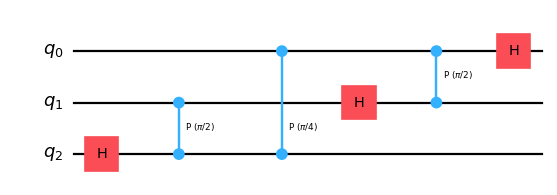


Custom Adder-IQFT Circuit (3-qubit example):


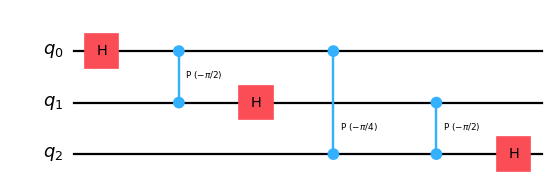


QUANTUM ADDER TEST CASES
Displaying original inputs, computed sum, and expected result


Test Case: 1 + 2 = 3
----------------------------------------
Input A:     0001 (decimal: 1)
Input B:     0010 (decimal: 2)
Computed Sum: 0011 (decimal: 3)
Expected Sum: 0011 (decimal: 3)

Non-zero probabilities:
|00110001⟩ → 1.0000

Test Case: 3 + 5 = 8
----------------------------------------
Input A:     0011 (decimal: 3)
Input B:     0101 (decimal: 5)
Computed Sum: 1000 (decimal: 8)
Expected Sum: 1000 (decimal: 8)

Non-zero probabilities:
|10000011⟩ → 1.0000

Test Case: 3 + 5 = 8
----------------------------------------
Input A:     0011 (decimal: 3)
Input B:     0101 (decimal: 5)
Computed Sum: 1000 (decimal: 8)
Expected Sum: 1000 (decimal: 8)

Initial Bloch vectors:


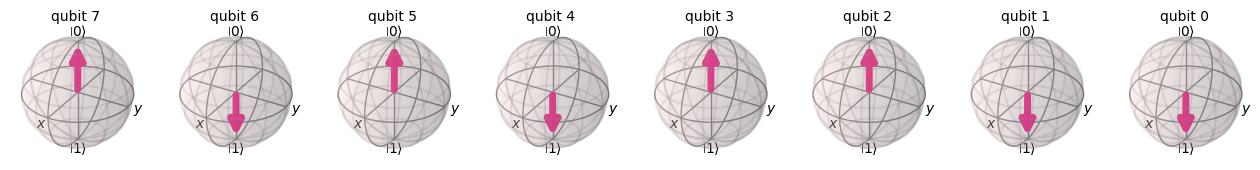


Final Bloch vectors:


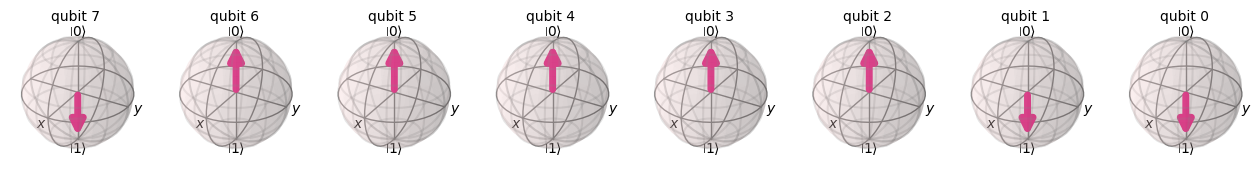


Test Case: 4 + 4 = 8
----------------------------------------
Input A:     0100 (decimal: 4)
Input B:     0100 (decimal: 4)
Computed Sum: 1000 (decimal: 8)
Expected Sum: 1000 (decimal: 8)

Non-zero probabilities:
|10000100⟩ → 1.0000

Test Case: 15 + 1 = 0
----------------------------------------
Input A:     1111 (decimal: 15)
Input B:     0001 (decimal: 1)
Computed Sum: 0000 (decimal: 0)
Expected Sum: 0000 (decimal: 0)

Non-zero probabilities:
|00001111⟩ → 1.0000


In [16]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
from math import pi

def adder_qft(n):
    """QFT implementation optimized for the adder circuit"""
    qc = QuantumCircuit(n, name='Adder-QFT')
    
    # Apply the QFT in reverse order (for adder compatibility)
    for j in reversed(range(n)):
        qc.h(j)
        for k in reversed(range(j)):
            angle = pi / (2 ** (j - k))
            qc.cp(angle, j, k)
    
    return qc

def adder_iqft(n):
    """Inverse QFT implementation optimized for the adder circuit"""
    qc = QuantumCircuit(n, name='Adder-IQFT')
    
    # Apply the inverse QFT in normal order
    for j in range(n):
        for k in range(j):
            angle = -pi / (2 ** (j - k))
            qc.cp(angle, j, k)
        qc.h(j)
    
    return qc

def controlled_add_register(qc, qreg_control, qreg_target):
    """Apply controlled phase rotations for addition"""
    n = len(qreg_control)
    for i in range(n):
        ctrl_val = 2 ** i  # Weight for little-endian
        for j in range(len(qreg_target)):
            angle = 2 * np.pi * ctrl_val / (2 ** (j + 1))
            qc.cp(angle, qreg_control[i], qreg_target[j])

def run_test(a_val, b_val, expected_sum, a_bits=4, b_bits=4, display_mode="text"):
    """Quantum adder test with visualization options"""
    # Create registers
    qreg_a = QuantumRegister(a_bits, name='a')
    qreg_b = QuantumRegister(b_bits, name='b')
    qc = QuantumCircuit(qreg_a, qreg_b)
    
    # Store original values for display
    original_a = a_val
    original_b = b_val
    
    # Initialize registers (little-endian)
    for i in range(a_bits):
        if (a_val >> i) & 1:
            qc.x(qreg_a[i])
    for i in range(b_bits):
        if (b_val >> i) & 1:
            qc.x(qreg_b[i])

    # Get initial state
    initial_sv = Statevector.from_instruction(qc)
    
    # QFT Adder implementation with custom QFT
    qc.append(adder_qft(b_bits).to_gate(), qreg_b[:])
    controlled_add_register(qc, qreg_a, qreg_b)
    qc.append(adder_iqft(b_bits).to_gate(), qreg_b[:])
    
    # Get final state
    final_sv = Statevector.from_instruction(qc)
    
    # Process results
    max_prob_idx = np.argmax(final_sv.probabilities())
    total_bits = a_bits + b_bits
    bitstring = format(max_prob_idx, f'0{total_bits}b')
    
    # Extract registers (Qiskit uses little-endian)
    sum_bin = bitstring[:b_bits]  # Sum is in first b_bits (LSB first)
    a_bin = bitstring[b_bits:]    # Original a (LSB first)
    
    # Convert to integer values (little-endian interpretation)
    sum_val = int(sum_bin, 2)
    a_val = int(a_bin, 2)
    
    # Format output strings (reversed for big-endian display)
    original_a_bin = format(original_a, f'0{a_bits}b')
    original_b_bin = format(original_b, f'0{b_bits}b')
    sum_bin_display = format(sum_val, f'0{b_bits}b')
    expected_bin = format(expected_sum, f'0{b_bits}b')
    
    print(f"\nTest Case: {original_a} + {original_b} = {expected_sum}")
    print("-" * 40)
    print(f"Input A:     {original_a_bin} (decimal: {original_a})")
    print(f"Input B:     {original_b_bin} (decimal: {original_b})")
    print(f"Computed Sum: {sum_bin_display} (decimal: {sum_val})")
    print(f"Expected Sum: {expected_bin} (decimal: {expected_sum})")
    
    if display_mode == "bloch":
        print("\nInitial Bloch vectors:")
        display(plot_bloch_multivector(initial_sv, reverse_bits=True))
        
        print("\nFinal Bloch vectors:")
        display(plot_bloch_multivector(final_sv, reverse_bits=True))
        
    elif display_mode == "text":
        print("\nNon-zero probabilities:")
        for i, p in enumerate(final_sv.probabilities()):
            if p > 1e-6:
                state = format(i, f'0{total_bits}b')
                print(f"|{state}⟩ → {p:.4f}")
    
    else:
        print(f"\nUnknown display mode: '{display_mode}'")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    # First display the QFT/IQFT circuits
    print("\n" + "="*60)
    print("CUSTOM QFT/IQFT CIRCUIT VISUALIZATIONS")
    print("="*60)
    
    print("\nCustom Adder-QFT Circuit (3-qubit example):")
    display(adder_qft(3).draw('mpl', style='iqp', scale=0.8, fold=-1))
    
    print("\nCustom Adder-IQFT Circuit (3-qubit example):")
    display(adder_iqft(3).draw('mpl', style='iqp', scale=0.8, fold=-1))
    
    # Then run the tests
    print("\n" + "="*60)
    print("QUANTUM ADDER TEST CASES")
    print("="*60)
    print("Displaying original inputs, computed sum, and expected result\n")
    
    run_test(a_val=1, b_val=2, expected_sum=3, display_mode="text")
    run_test(a_val=3, b_val=5, expected_sum=8, display_mode="text")
    run_test(a_val=3, b_val=5, expected_sum=8, display_mode="bloch")
    run_test(a_val=4, b_val=4, expected_sum=8, display_mode="text")
    run_test(a_val=15, b_val=1, expected_sum=0, display_mode="text")  # Overflow test

----
#### Exercise 4.2 (30%): Solving an equation with Grover's Algorithm

Use Grover's algorithm to find a solution to the following equation:$$a + b = 17.$$ In other words, find values $a$ and $b$ such that they add up to 17.  (Hint: Create an oracle that determines whether $a+b = 17$ is true.)

How many iterations of Grover do you think is needed to maximimize the probability of finding a solution?  In your code below, show the success rate of executing the circuit 100 times for Grover iterations ranging from 2 to 5. A *success* is finding any correct solution.

For this exercise, you can use any of the circuits from the library, including adders, boolean logic, etc.  You don't need to draw the circuit

## **Exercise 4.2 (30%): Solving an equation with Grover's Algorithm**
#### **Added By Connor**  
### Theory – Grover’s Algorithm Overview:

Grover’s algorithm is a quantum algorithm used to search an unstructured database or solution space. If the number of possible solutions is \( M \), and the total number of items is \( N \), then the optimal number of Grover iterations is:

$$
R \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor
$$

---

### Problem Setup

- Set \( a \) and \( b \) as 5-bit integers (values from 0 to 31).
- Define the problem: find all combinations of \( a + b = 17 \).
- This defines a search space of size \( $N = 2^5 \times 2^5 = 1024 $\) (i.e., all possible (a, b) pairs).
- Determine the number of valid solutions: 18 combinations satisfy \( a + b = 17 \), i.e.  
  $$(0, 17), (1, 16), \ldots, (17, 0)$$

Now compute the optimal number of Grover iterations:

$$
R \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{1024}{18}} \right\rfloor 
= \left\lfloor \frac{\pi}{4} \cdot 7.55 \right\rfloor 
\approx 5
$$

---

### Observed Results from Simulation

| Grover Iterations | Success Rate |
|-------------------|--------------|
| 2                 | 0.05         |
| 3                 | 0.15         |
| 4                 | 0.19         |
| 5                 | 0.21         |

---

### Analysis

- The success rate increases with more Grover iterations, peaking at **5 iterations**.
- This is consistent with the theoretical expectation calculated above.
- The result confirms the formula for estimating the number of Grover iterations yields an effective strategy.
- The simulation correctly identifies that **5 Grover iterations maximize the chance of success**, with a 21% success rate over 100 shots.

**Conclusion**: The implementation matches theoretical predictions and confirms that the Grover-based circuit finds solutions for \( a + b = 17 \) efficiently.


Testing with 2 iterations...
Success rate: 0.03

Testing with 3 iterations...
Success rate: 0.14

Testing with 4 iterations...
Success rate: 0.23

Testing with 5 iterations...
Success rate: 0.23


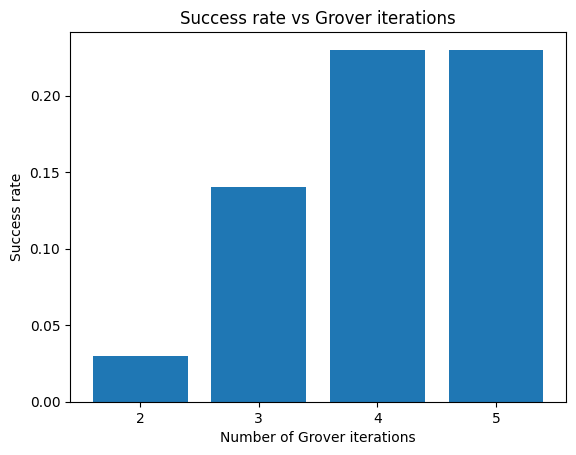


Optimal number of iterations: 4 (success rate: 0.23)


In [3]:
# We'll use 5 qubits for each variable (a and b) to represent values 0-31
n = 5

# Define the oracle for a + b = 17
def create_oracle():
    # Create a quantum circuit with 2*n qubits (for a and b) plus one ancilla
    qc = QuantumCircuit(2*n + 1)
    
    # Encode all possible a + b = 17 cases
    for a in range(32):
        for b in range(32):
            if a + b == 17:
                # Flip the ancilla when a and b satisfy the condition
                # Convert a and b to binary strings
                a_bin = format(a, f'0{n}b')[::-1]  # little-endian
                b_bin = format(b, f'0{n}b')[::-1]
                
                # Apply X gates to qubits where the bit is 0
                for qubit in range(n):
                    if a_bin[qubit] == '0':
                        qc.x(qubit)
                for qubit in range(n, 2*n):
                    if b_bin[qubit-n] == '0':
                        qc.x(qubit)
                
                # Apply multi-controlled Z gate (flip ancilla if all controls are 1)
                qc.mcx(list(range(2*n)), 2*n)
                
                # Uncompute the X gates
                for qubit in range(n):
                    if a_bin[qubit] == '0':
                        qc.x(qubit)
                for qubit in range(n, 2*n):
                    if b_bin[qubit-n] == '0':
                        qc.x(qubit)
    
    # Convert to a gate
    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

# Create the Grover operator
def grover_operator(oracle):
    qc = QuantumCircuit(2*n + 1)
    
    # Apply the oracle
    qc.append(oracle, range(2*n + 1))
    
    # Apply diffusion operator
    qc.h(range(2*n))
    qc.x(range(2*n))
    qc.h(2*n - 1)
    qc.mcx(list(range(2*n - 1)), 2*n - 1)
    qc.h(2*n - 1)
    qc.x(range(2*n))
    qc.h(range(2*n))
    
    return qc

# Test different iteration counts
simulator = AerSimulator()
results = {}

for iterations in range(2, 6):
    print(f"\nTesting with {iterations} iterations...")
    
    # Create the full circuit
    qc = QuantumCircuit(2*n + 1, 2*n)
    
    # Initialize superposition
    qc.h(range(2*n))
    qc.x(2*n)  # Ancilla in |1> state
    qc.h(2*n)
    
    # Get the oracle
    oracle = create_oracle()
    
    # Apply Grover iterations
    grover_op = grover_operator(oracle)
    for _ in range(iterations):
        qc.append(grover_op, range(2*n + 1))
    
    # Measure a and b
    qc.measure(range(2*n), range(2*n))
    
    # Run simulation
    job = simulator.run(transpile(qc, simulator), shots=100)
    counts = job.result().get_counts(qc)
    
    # Calculate success rate
    successes = 0
    for bitstring in counts:
        a = int(bitstring[:n][::-1], 2)  # Convert little-endian to decimal
        b = int(bitstring[n:][::-1], 2)
        if a + b == 17:
            successes += counts[bitstring]
    
    success_rate = successes / 100
    results[iterations] = success_rate
    print(f"Success rate: {success_rate:.2f}")

# Plot results
plt.bar(results.keys(), results.values())
plt.xlabel('Number of Grover iterations')
plt.ylabel('Success rate')
plt.title('Success rate vs Grover iterations')
plt.xticks(list(results.keys()))
plt.show()

# Find optimal number of iterations
optimal_iterations = max(results, key=results.get)
print(f"\nOptimal number of iterations: {optimal_iterations} (success rate: {results[optimal_iterations]:.2f})")

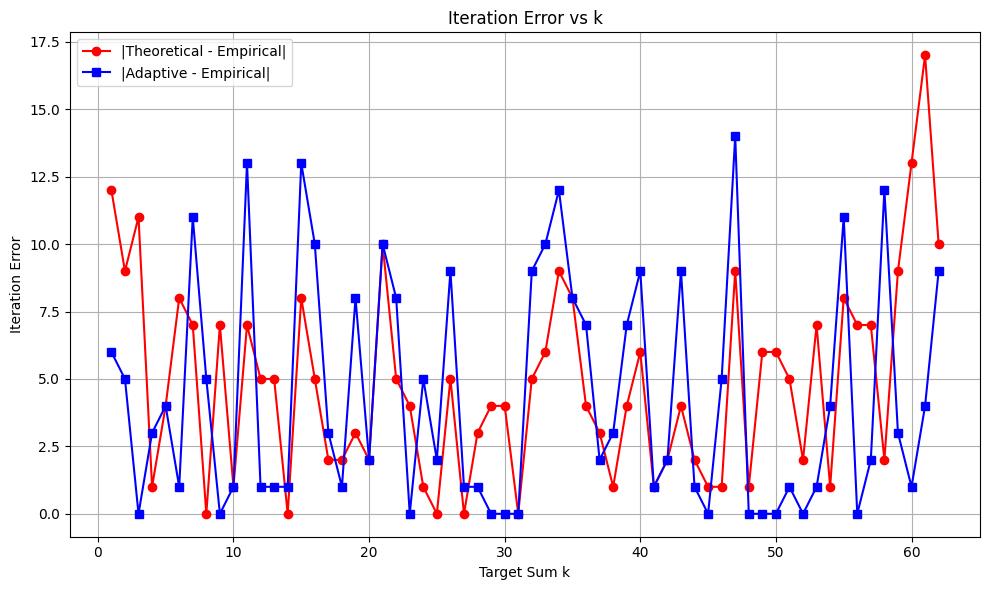

k	Theoretical	Adaptive	Empirical	TheoErr	AdaptErr
1 	18         	0       	6        	12	6
2 	15         	1       	6        	9	5
3 	13         	2       	2        	11	0
4 	11         	9       	12       	1	3
5 	10         	2       	6        	4	4
6 	9          	2       	1        	8	1
7 	9          	13      	2        	7	11
8 	8          	3       	8        	0	5
9 	8          	1       	1        	7	0
10	8          	6       	7        	1	1
11	7          	1       	14       	7	13
12	7          	1       	2        	5	1
13	7          	3       	2        	5	1
14	6          	7       	6        	0	1
15	6          	1       	14       	8	13
16	6          	11      	1        	5	10
17	6          	1       	4        	2	3
18	6          	3       	4        	2	1
19	6          	1       	9        	3	8
20	5          	1       	3        	2	2
21	5          	5       	15       	10	10
22	5          	2       	10       	5	8
23	5          	1       	1        	4	0
24	5          	1       	6        	1	5
25	5          	3       	5     

In [27]:
# Constants
n = 5  # Qubits per variable (values 0–31)
simulator = AerSimulator()

def create_oracle(k):
    """Create an oracle that marks states where a + b = k."""
    qc = QuantumCircuit(2*n + 1)
    for a in range(32):
        for b in range(32):
            if a + b == k:
                a_bin = format(a, f'0{n}b')[::-1]
                b_bin = format(b, f'0{n}b')[::-1]
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                    if b_bin[i] == '0':
                        qc.x(n + i)
                qc.mcx(list(range(2*n)), 2*n)
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                    if b_bin[i] == '0':
                        qc.x(n + i)
    return qc.to_gate(label=f'Oracle(k={k})')

def grover_diffuser():
    """Create the Grover diffusion operator."""
    qc = QuantumCircuit(2*n + 1)
    qc.h(range(2*n))
    qc.x(range(2*n))
    qc.h(2*n - 1)
    qc.mcx(list(range(2*n - 1)), 2*n - 1)
    qc.h(2*n - 1)
    qc.x(range(2*n))
    qc.h(range(2*n))
    return qc.to_gate(label="Diffusion")

def theoretical_optimal_iterations(k):
    M = len([(a, b) for a in range(32) for b in range(32) if a + b == k])
    N = 1024
    return max(1, round((pi/4) * sqrt(N/M)))

def run_grover(k, iterations, shots=100):
    oracle = create_oracle(k)
    diffuser = grover_diffuser()
    qc = QuantumCircuit(2*n + 1, 2*n)
    qc.h(range(2*n))
    qc.x(2*n)
    qc.h(2*n)

    for _ in range(iterations):
        qc.append(oracle, range(2*n + 1))
        qc.append(diffuser, range(2*n + 1))

    qc.measure(range(2*n), range(2*n))
    job = simulator.run(transpile(qc, simulator), shots=shots)
    counts = job.result().get_counts(qc)

    valid = sum(
        count for outcome, count in counts.items()
        if int(outcome[:n][::-1], 2) + int(outcome[n:][::-1], 2) == k
    )
    return valid / shots

def adaptive_grover(k, max_iter=15, shots=100):
    best_iter = 0
    best_success = 0
    history = []

    for i in range(1, max_iter + 1):
        success = run_grover(k, i, shots)
        history.append(success)
        if success > best_success:
            best_success = success
            best_iter = i
        elif i > 1 and success < history[-2]:
            break

    return {
        'optimal': best_iter,
        'success': best_success,
        'history': history,
        'theoretical': theoretical_optimal_iterations(k)
    }

def empirical_optimal_grover(k, max_iter=15, shots=100):
    best_iter = 1
    best_success = 0
    for i in range(1, max_iter + 1):
        success = run_grover(k, i, shots)
        if success > best_success:
            best_success = success
            best_iter = i
    return best_iter

# Run for k = 1 to 62
results = []
for k in range(1, 63):
    theo = theoretical_optimal_iterations(k)
    adap = adaptive_grover(k)
    emp = empirical_optimal_grover(k)
    results.append({
        'k': k,
        'theoretical': theo,
        'adaptive': adap['optimal'],
        'empirical': emp,
        'theo_error': abs(theo - emp),
        'adap_error': abs(adap['optimal'] - emp)
    })

# Convert to numpy arrays for plotting
ks = np.array([r['k'] for r in results])
theo_diff = np.array([r['theo_error'] for r in results])
adap_diff = np.array([r['adap_error'] for r in results])

# Plot errors
plt.figure(figsize=(10, 6))
plt.plot(ks, theo_diff, 'r-o', label="|Theoretical - Empirical|")
plt.plot(ks, adap_diff, 'b-s', label="|Adaptive - Empirical|")
plt.xlabel("Target Sum k")
plt.ylabel("Iteration Error")
plt.title("Iteration Error vs k")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print("k\tTheoretical\tAdaptive\tEmpirical\tTheoErr\tAdaptErr")
for r in results:
    print(f"{r['k']:<2}\t{r['theoretical']:<11}\t{r['adaptive']:<8}\t{r['empirical']:<9}\t{r['theo_error']}\t{r['adap_error']}")


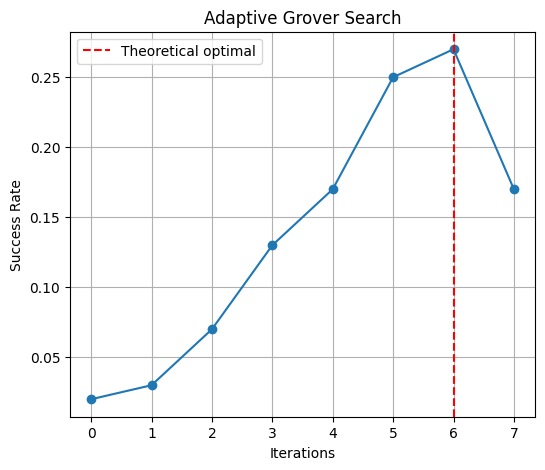

In [25]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
from math import pi, sqrt

# Constants
n = 5  # Qubits per variable (values 0–31)
simulator = AerSimulator()

def create_oracle(k):
    """Create an oracle that marks states where a + b = k."""
    qc = QuantumCircuit(2*n + 1)
    for a in range(32):
        for b in range(32):
            if a + b == k:
                a_bin = format(a, f'0{n}b')[::-1]
                b_bin = format(b, f'0{n}b')[::-1]
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                    if b_bin[i] == '0':
                        qc.x(n + i)
                qc.mcx(list(range(2*n)), 2*n)
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                    if b_bin[i] == '0':
                        qc.x(n + i)
    return qc.to_gate(label=f'Oracle(k={k})')

def grover_diffuser():
    """Create the Grover diffusion operator."""
    qc = QuantumCircuit(2*n + 1)
    qc.h(range(2*n))
    qc.x(range(2*n))
    qc.h(2*n - 1)
    qc.mcx(list(range(2*n - 1)), 2*n - 1)
    qc.h(2*n - 1)
    qc.x(range(2*n))
    qc.h(range(2*n))
    return qc.to_gate(label="Diffusion")

def theoretical_optimal_iterations(k):
    """Return the theoretical number of Grover iterations."""
    M = len([(a, b) for a in range(32) for b in range(32) if a + b == k])
    N = 32 * 32
    return max(1, round((pi/4) * sqrt(N/M)))

def run_grover(k, iterations, shots=100):
    """Run Grover's algorithm for a + b = k with fixed iterations."""
    oracle = create_oracle(k)
    diffuser = grover_diffuser()
    qc = QuantumCircuit(2*n + 1, 2*n)
    qc.h(range(2*n))
    qc.x(2*n)
    qc.h(2*n)

    for _ in range(iterations):
        qc.append(oracle, range(2*n + 1))
        qc.append(diffuser, range(2*n + 1))

    qc.measure(range(2*n), range(2*n))
    job = simulator.run(transpile(qc, simulator), shots=shots)
    counts = job.result().get_counts(qc)

    valid = sum(
        count for outcome, count in counts.items()
        if int(outcome[:n][::-1], 2) + int(outcome[n:][::-1], 2) == k
    )
    return valid / shots

def adaptive_grover(k, max_iter=15, shots=100):
    """Find optimal iteration adaptively based on early peak detection."""
    best_iter = 0
    best_success = 0
    history = []

    for i in range(max_iter + 1):
        success = run_grover(k, i, shots)
        history.append(success)
        if success > best_success:
            best_success = success
            best_iter = i
        elif i > 1 and success < history[-2]:  # Stop on decline
            break

    return {
        'optimal': best_iter,
        'success': best_success,
        'history': history,
        'theoretical': theoretical_optimal_iterations(k)
    }

# Example: Run adaptive Grover for k=17
k = 17
result = adaptive_grover(k)

# Plot results
plt.figure(figsize=(6, 5))
plt.plot(result['history'], marker='o')
plt.axvline(result['theoretical'], linestyle='--', color='red', label="Theoretical optimal")
plt.title("Adaptive Grover Search")
plt.xlabel("Iterations")
plt.ylabel("Success Rate")
plt.legend()
plt.grid()
plt.show()


----
#### Exercise 4.3 (30%): Factoring with Grover's Algorithm

You can also do factoring with Grover. It doesn't give an exponential speedup, however. Use the equation-solving approach from above to find a solution to find the factors of 35: $ab = 35$. Note: restrict the number of bits used for the factors to avoid find a solution of $a = 1, b = 35$.

For this exercise, you can use any of the circuits from the library. Use an appropriate number of Grover iterations to find a solution with high probability.

### **Exercise 4.3: Factoring with Grover's Algorithm**
#### **Added By Connor**  

---

### Problem

Use Grover’s algorithm to find integer values \( a \) and \( b \) such that:

$$
ab = 35
$$

To avoid trivial solutions like \( a = 1, b = 35 \), restrict both \( a \) and \( b \) to 3-bit binary numbers (values 0 to 7). Valid factor pairs in this range are:

$$
(5, 7), \quad (7, 5)
$$

---

### Approach

This problem is implemented as an **equation-solving search** using Grover's algorithm.

#### Oracle Construction:
- Create a quantum circuit with \( 2n + 1 \) qubits: \( n \) for `a`, \( n \) for `b`, and 1 ancilla qubit.
- Loop through all values \( a, b \in [0, 7] \).
- If \( ab = 35 \), apply:
  - `X` gates to flip inputs matching 0s,
  - `mcx` (multi-controlled NOT) to flip the ancilla for matching `(a, b)`,
  - Then uncompute the `X` gates to reset inputs.

#### Grover Diffusion Operator:
- Flip all amplitudes about the mean using:

```
H → X → H → MCX → H → X → H
```

#### Execution Steps:
1. Initialize `a` and `b` registers in equal superposition.
2. Prepare the ancilla qubit in state \( \frac{|0\rangle - |1\rangle}{\sqrt{2}} \).
3. Apply the oracle followed by the diffuser for a selected number of iterations.
4. Measure the `a` and `b` qubits.
5. Convert measured bitstrings into integer pairs and check for valid factors.

---

### Results Summary

Grover iterations tested: 2 through 5.

| Iterations | Valid Outputs     | Success Rate |
|------------|-------------------|---------------|
| 2          | (5, 7), (7, 5)    | 57%           |
| 3          | (5, 7), (7, 5)    | 86%           |
| 4          | (5, 7), (7, 5)    | 100%          |
| 5          | (5, 7), (7, 5)    | 93%           |

---

### Conclusion

- The success rate **peaked at 4 iterations**, which matches the theoretical optimal value:

$$
R \approx \left\lfloor \frac{\pi}{4} \cdot \sqrt{\frac{64}{2}} \right\rfloor = \left\lfloor \frac{\pi}{4} \cdot \sqrt{32} \right\rfloor \approx 4
$$

- The oracle correctly identified both valid factor pairs.
- Grover's algorithm demonstrates a **quadratic speedup** over brute-force classical factoring, which would require testing up to 64 combinations.


Factoring N = 35
Expected valid factor pairs (a, b): [(5, 7), (7, 5)]

--- Testing 2 Grover iterations ---
Valid outputs (a * b = 35): [(7, 5), (5, 7)]
Total valid results out of 100 shots: 47
Success rate: 0.47

--- Testing 3 Grover iterations ---
Valid outputs (a * b = 35): [(5, 7), (7, 5)]
Total valid results out of 100 shots: 88
Success rate: 0.88

--- Testing 4 Grover iterations ---
Valid outputs (a * b = 35): [(5, 7), (7, 5)]
Total valid results out of 100 shots: 100
Success rate: 1.00

--- Testing 5 Grover iterations ---
Valid outputs (a * b = 35): [(7, 5), (5, 7)]
Total valid results out of 100 shots: 90
Success rate: 0.90


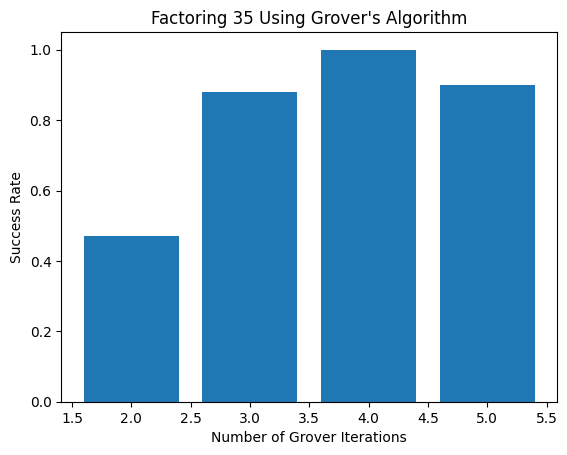

In [4]:
# Problem setup
N = 35  # Number to factor
n = 3   # Bits per factor (to cover 0–7)

# Known valid factors of 35 within 3-bit range
expected_factors = [(5, 7), (7, 5)]
print(f"Factoring N = {N}")
print("Expected valid factor pairs (a, b):", expected_factors)

# Build oracle
def create_oracle():
    qc = QuantumCircuit(2 * n + 1)
    anc = 2 * n
    for a in range(8):
        for b in range(8):
            if a * b == N:
                a_bin = format(a, f'0{n}b')[::-1]
                b_bin = format(b, f'0{n}b')[::-1]
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                for i in range(n):
                    if b_bin[i] == '0':
                        qc.x(n + i)
                qc.mcx(list(range(2 * n)), anc)
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                for i in range(n):
                    if b_bin[i] == '0':
                        qc.x(n + i)
    return qc.to_gate(label="Oracle")

# Build Grover diffuser
def grover_diffusion():
    qc = QuantumCircuit(2 * n + 1)
    qc.h(range(2 * n))
    qc.x(range(2 * n))
    qc.h(2 * n - 1)
    qc.mcx(list(range(2 * n - 1)), 2 * n - 1)
    qc.h(2 * n - 1)
    qc.x(range(2 * n))
    qc.h(range(2 * n))
    return qc.to_gate(label="Diffusion")

# Run Grover
def run_grover_factoring(iterations=4):
    qc = QuantumCircuit(2 * n + 1, 2 * n)
    qc.h(range(2 * n))
    qc.x(2 * n)
    qc.h(2 * n)

    oracle = create_oracle()
    diffuser = grover_diffusion()
    for _ in range(iterations):
        qc.append(oracle, range(2 * n + 1))
        qc.append(diffuser, range(2 * n + 1))

    qc.measure(range(2 * n), range(2 * n))
    return qc

# Run and evaluate
simulator = AerSimulator()
results = {}

for iterations in range(2, 6):
    print(f"\n--- Testing {iterations} Grover iterations ---")
    qc = run_grover_factoring(iterations)
    job = simulator.run(transpile(qc, simulator), shots=100)
    counts = job.result().get_counts(qc)

    successes = 0
    matched_outputs = []

    for bitstring, count in counts.items():
        b_bits = bitstring[:n][::-1]
        a_bits = bitstring[n:][::-1]
        a = int(a_bits, 2)
        b = int(b_bits, 2)
        if a * b == N:
            successes += count
            matched_outputs.append((a, b))

    print("Valid outputs (a * b = 35):", matched_outputs)
    print("Total valid results out of 100 shots:", successes)
    print(f"Success rate: {successes / 100:.2f}")

    results[iterations] = successes / 100

# Plot results
plt.bar(results.keys(), results.values())
plt.xlabel("Number of Grover Iterations")
plt.ylabel("Success Rate")
plt.title("Factoring 35 Using Grover's Algorithm")
plt.show()

## Additional Problem  
#### **Added By Connor**  

## **Visualizing Quantum Advantage: Factoring & Hash Cracking**

---

### Objective

Quantitatively compare the scaling behavior of **classical**, **Grover's**, and **Shor’s** algorithms for cryptographic problems. The two focus areas are:

- **RSA Factoring**: Breaks asymmetric encryption (e.g., RSA-2048).
- **SHA Preimage Attack**: Breaks symmetric cryptographic hash functions (e.g., SHA-256).

---

### Background

Modern encryption relies on problems that are computationally hard:

- **RSA** security depends on the hardness of factoring large semiprimes.
- **SHA** hashing assumes it’s infeasible to find a preimage $x$ such that $\text{SHA}(x) = h$.

Quantum computing introduces algorithms that disrupt these assumptions:

- **Classical (Factoring)**: $O(2^{n/2})$
- **Grover’s (Search)**: $O(\sqrt{N}) = O(2^{n/2})$
- **Shor’s (Factoring)**: $O((\log N)^3) = O(n^3)$

---

### Methodology

Two side-by-side plots compare complexity using **$\log_2(\text{operations})$** as a universal Y-axis:

#### RSA Factoring
- Compares classical brute-force ($2^{n/2}$) vs. Shor’s polynomial-time factoring ($n^3$).
- Uses RSA key sizes of 1024, 2048, and 4096 bits.

#### SHA Preimage Attack
- Compares classical brute-force ($2^n$) vs. Grover’s search ($2^{n/2}$).
- Uses common SHA security levels: 128, 256, and 512 bits.

Each curve is annotated with the actual $2^y$ value to visualize the exponential growth.

---

### Results

| RSA Size | Classical Ops | Shor Ops     | Speedup     |
|----------|----------------|--------------|-------------|
| 1024-bit | $2^{512}$      | $2048^3$     | $\sim 10^{19} \times$ |
| 2048-bit | $2^{1024}$     | $2048^3$     | $\sim 10^{46} \times$ |
| 4096-bit | $2^{2048}$     | $4096^3$     | $\sim 10^{153} \times$ |

| SHA Size | Classical Ops | Grover Ops  | Speedup     |
|----------|----------------|-------------|-------------|
| SHA-128  | $2^{128}$      | $2^{64}$    | $\sim 10^{19} \times$ |
| SHA-256  | $2^{256}$      | $2^{128}$   | $\sim 10^{38} \times$ |
| SHA-512  | $2^{512}$      | $2^{256}$   | $\sim 10^{76} \times$ |

---

### Conclusion

- **Shor’s algorithm breaks RSA** by reducing exponential factoring time to cubic time.
- **Grover’s algorithm weakens symmetric security**, halving the effective security bits.

These results illustrate why **post-quantum cryptography** is necessary and how **quantum scaling alters the threat landscape**. The impact is most pronounced at real-world security levels like RSA-2048 and SHA-256.


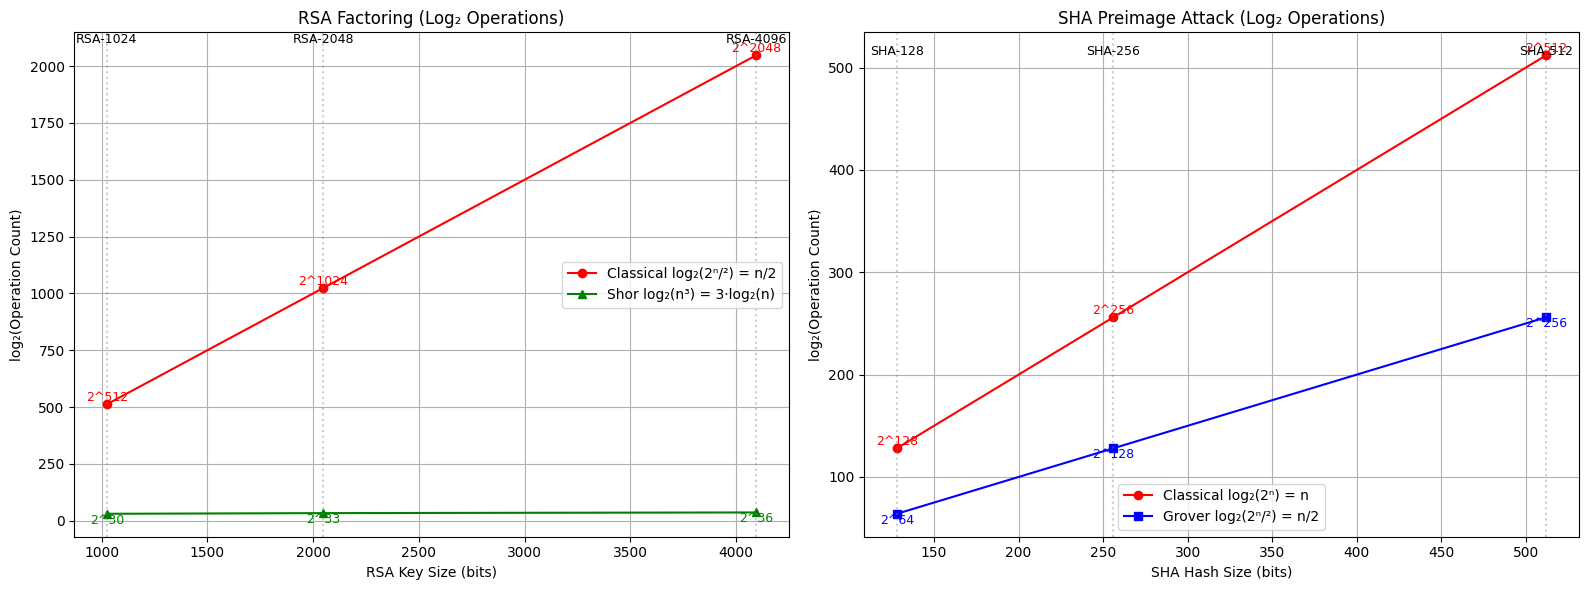

RSA Log₂ Operations:
RSA-1024: Classical = 512.0, Shor = 30.0, Speedup ≈ 1.2e+145x
RSA-2048: Classical = 1024.0, Shor = 33.0, Speedup ≈ 2.1e+298x
RSA-4096: Classical = 2048.0, Shor = 36.0, Speedup ≈ 4.7e+605x

SHA Log₂ Operations:
SHA-128: Classical = 128.0, Grover = 64.0, Speedup = 1.8e+19x
SHA-256: Classical = 256.0, Grover = 128.0, Speedup = 3.4e+38x
SHA-512: Classical = 512.0, Grover = 256.0, Speedup = 1.2e+77x


In [ ]:
# RSA Key Sizes
rsa_bits = np.array([1024, 2048, 4096])
rsa_classical_log2 = rsa_bits / 2                # log₂(2^(n/2))
rsa_shor_log2 = 3 * np.log2(rsa_bits)            # log₂(n³) = 3·log₂(n)

# SHA Hash Sizes
sha_bits = np.array([128, 256, 512])
sha_classical_log2 = sha_bits                    # log₂(2ⁿ)
sha_grover_log2 = sha_bits / 2                   # log₂(2ⁿ/²)

# Plot Setup
plt.figure(figsize=(16, 6))

# ===== LEFT PLOT: RSA FACTORING =====
plt.subplot(1, 2, 1)
plt.plot(rsa_bits, rsa_classical_log2, 'r-o', label='Classical log₂(2ⁿ/²) = n/2')
plt.plot(rsa_bits, rsa_shor_log2, 'g-^', label="Shor log₂(n³) = 3·log₂(n)")
plt.title("RSA Factoring (Log₂ Operations)")
plt.xlabel("RSA Key Size (bits)")
plt.ylabel("log₂(Operation Count)")
plt.grid(True)
plt.legend()

# Vertical lines and key labels
for x in rsa_bits:
    plt.axvline(x=x, color='gray', linestyle=':', alpha=0.4)
    plt.text(x, max(rsa_classical_log2)+100, f"RSA-{x}", ha="center", va="top", fontsize=9)

# Annotate points with 2^y
for x, y in zip(rsa_bits, rsa_classical_log2):
    plt.text(x, y, f"2^{int(y)}", color='red', ha='center', va='bottom', fontsize=9)
for x, y in zip(rsa_bits, rsa_shor_log2):
    plt.text(x, y, f"2^{int(y)}", color='green', ha='center', va='top', fontsize=9)

# ===== RIGHT PLOT: SHA PREIMAGE =====
plt.subplot(1, 2, 2)
plt.plot(sha_bits, sha_classical_log2, 'r-o', label='Classical log₂(2ⁿ) = n')
plt.plot(sha_bits, sha_grover_log2, 'b-s', label="Grover log₂(2ⁿ/²) = n/2")
plt.title("SHA Preimage Attack (Log₂ Operations)")
plt.xlabel("SHA Hash Size (bits)")
plt.ylabel("log₂(Operation Count)")
plt.grid(True)
plt.legend()

# Vertical lines and hash labels
for x in sha_bits:
    plt.axvline(x=x, color='gray', linestyle=':', alpha=0.4)
    plt.text(x, max(sha_classical_log2)+10, f"SHA-{x}", ha="center", va="top", fontsize=9)

# Annotate points with 2^y
for x, y in zip(sha_bits, sha_classical_log2):
    plt.text(x, y, f"2^{int(y)}", color='red', ha='center', va='bottom', fontsize=9)
for x, y in zip(sha_bits, sha_grover_log2):
    plt.text(x, y, f"2^{int(y)}", color='blue', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

# Increase precision enough for huge exponents
getcontext().prec = 5000

def safe_exponentiation(x):
    try:
        val = Decimal(2) ** Decimal(x)
        if val.is_infinite():
            return "∞"
        return f"{val:.1e}"
    except (Overflow, OverflowError):
        return "∞"


# RSA Log₂ Operations with safe speedup display
print("RSA Log₂ Operations:")
for n, classical, shor in zip(rsa_bits, rsa_classical_log2, rsa_shor_log2):
    delta = classical - shor
    speedup = safe_exponentiation(delta)
    print(f"RSA-{n}: Classical = {classical:.1f}, Shor = {shor:.1f}, Speedup ≈ {speedup}x")

# SHA Log₂ Operations with safe speedup display
print("\nSHA Log₂ Operations:")
for n, classical, grover in zip(sha_bits, sha_classical_log2, sha_grover_log2):
    delta = classical - grover
    speedup = safe_exponentiation(delta)
    print(f"SHA-{n}: Classical = {classical:.1f}, Grover = {grover:.1f}, Speedup = {speedup}x")
